# Neste notebook faremos a simulação por dinâmica molecular do gás argônio superfluido à 94 K e 1 atm.

Antes de dar início à simulação, deveremos instalar o pacote M3L responsável pela dinâmica molecular. Descomente a linha abaixo caso ele ainda não foi instalado no seu ambiente virtual.

In [1]:
#pip install -i https://test.pypi.org/simple/ m3l --extra-index-url https://pypi.org/simple/

In [2]:
#url = 'https://raw.githubusercontent.com/flavianowilliams/Notebooks/master/M3L/argon/Ar_94K_1atm.json'
#from urllib.request import urlopen
#file = urlopen(url)
#with open('Ar_94K.json','wb') as output:
#  output.write(file.read())
#
# carregando sistema físico
from m3l.structure import System as sys
import json
import numpy as np
#
system = sys()
system.loadSystem('Ar_94K_1atm.json')
#
# convertendo as unidades de medida
system.convertUnits()

In [3]:
# definindo o modelo de interação entre os átomos (campo de força)      
import m3l.force_field as ff
from m3l.force_field import Intermolecular as interff
from m3l.force_field import Molecules as mo
class Forces(ff.ForceField2):
    def __init__(self):
        super().__init__()
        self.van_der_waals = self.sites(
            interff.site(1, 1, 0.2385, 3.4), #site ID, atomic charge, Lennard-Jones parameters
        )
        self.electrostatic = 'coulomb'
        self.convertUnits()
#        self.molecules = mo.molecule(1),
#        )
#    def intermolecular(self.van_der_waals, rvdw = 11.0, rcoul = 11.0)
#        return self.van_der_waals
#        
model = Forces()
model()

(1, 0.0, 0.0, [[[1, 1]], [[0.0003802000129863748, 6.42506882808646]]])

In [4]:
# Etapa 3
# definindo o modelo estatístico (ensemble)
from m3l.molecular_dynamics import Ensemble as en
#
force_field = model()
#ensemble = en(temp_bath = 94, timestep = 1.0e-3, force_field = force_field, tstat = 2.0)
ensemble = en(temp_bath = 94, press_bath = 1.0, timestep = 1.0e-3, force_field = force_field, tstat = 1.0, pstat = 1.0)

In [5]:
rcm = [0.0, 0.0, 0.0]
for ra in system.ra:
    for i in range(3):
        rcm[i] =+ ra[i]
rcm = rcm/system.natom
rcm = rcm/system.ACONV

In [6]:
# Etapa 4
# executando ciclo MD
import time
import csv
import numpy as np
#
n_steps = 10000
with open('diff.csv', 'w', newline = '') as csvfile:
    fieldnames = ['time', 'dr']
    writer = csv.DictWriter(csvfile, fieldnames = fieldnames)
    writer.writeheader()
    for step in range(n_steps):
        system = ensemble(system)
        if step%10 == 0:
#        for i in range(system.natom):
#            dr = np.sqrt((system.ra[i][0]-rcm[0])**2+(system.ra[i][1]-rcm[1])**2+(system.ra[i][2]-rcm[2])**2)
            for ra in system.ra:
                dr = np.sqrt((ra[0])**2+(ra[1])**2+(ra[2])**2)
                writer.writerow({
                    'time': (step+1)*ensemble.timestep/system.TIMECONV,
                    'dr': dr/system.ACONV
#                    'xr': (ra[0])/system.ACONV,
#                    'yr': (ra[1])/system.ACONV,
#                    'zr': (ra[2])/system.ACONV,
                })

In [7]:
# Etapa opcional
# Gráfico de séries temporais de algumas variáveis termodinâmicas
import numpy as np
#import statistics as stats
dataset = np.loadtxt("diff.csv", dtype=np.float32, delimiter = ",", skiprows=1)
t_list = [item[0].item() for item in dataset]
r_list = [item[1].item() for item in dataset]
#x_list = [item[1].item() for item in dataset]
#y_list = [item[2].item() for item in dataset]
#z_list = [item[3].item() for item in dataset]

In [8]:
i_steps = 4
d_steps = int(len(t_list)/(i_steps*system.natom))
#g = 0
#for i in range(d_steps):
#    for j in range(i_steps):
#        if j == 0:
#            for k in range(system.natom):
#                ix = g+k
#        else:
#            for k in range(system.natom):
#                ix = g+k
#        g = g+system.natom
print(i_steps, d_steps)
#print(ix, len(dataset))

4 250


In [9]:
g = 0
msd = []
for i in range(i_steps):
    rel_list = []
    time_list = []
    for j in range(d_steps):
        if j == 0:
#            x0 = []
#            y0 = []
#            z0 = []
            r0 = []
            t0 = t_list[g]
            for k in range(system.natom):
                r0.append(r_list[g+k])
#                x0.append(x_list[g+k])
#                y0.append(y_list[g+k])
#                z0.append(z_list[g+k])
        else:
            soma = 0.0
            for k in range(system.natom):
                soma = soma + (r_list[g+k]-r0[k])**2
#                soma = soma + (abs((x_list[g+k]-x0[k])**2+(y_list[g+k]-y0[k])**2+(z_list[g+k]-z0[k])**2))
            rel_list.append(soma/system.natom.item())
            time_list.append(t_list[g+k]-t0)
        g = g + system.natom
    msd.append(time_list)
#        t1 = t_list[g-system.natom]
#    time = t1 - t0
#    time = (i+1)*ensemble.timestep/system.TIMECONV
#    rel = soma/(i_steps*system.natom.item())
#    rel_list.append(rel)

In [10]:
lista = np.array(msd)
msd_novo = np.mean(lista, axis = 0)

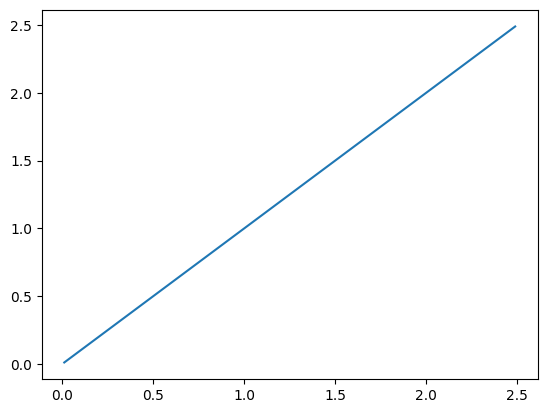

In [11]:
from matplotlib import pyplot as plt
#
plt.plot(time_list, msd_novo)

In [12]:
# limpando memória RAM
#del model
#del ensemble
#del system
#del dataset